# Investigate whether increasing facet distance in the contact region helps with element quality

In [1]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from tqdm import tqdm
import subprocess

# Initial runs with 14548R and 15006R
 - 15006R has very high cartilage std, so is potentially the hardest to optimise

In [3]:
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/study4/initialRuns1/params/full_params.json

SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 5.135s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 5.024s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 62.246s - ok
			RUN ID: -0-0-1
			Runtime: 58.864s - ok
			RUN ID: -0-0-2
			Runtime: 58.400s - ok
			RUN ID: -0-0-3
			Runtime: 58.532s - ok

SUBJECT: 15006R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 3.977s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 5.562s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 108.864s - ok
			RUN ID: -0-0-1
			Runtime: 109.314s - ok
			RUN ID: -0-0-2
			Runtime: 112.946s - ok
			RUN ID: -0-0-3
			Runtime: 111.223s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [2]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('outputs/study4') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study4') # path dir to save outputs in

study_prefix = 'initialRuns' # start of dir name of output_root in set_parameters
studies = ['1', '2a', '2b', '3a', '3b', '4', '5a', '5b'] # individual study identifier (end of dir name of output_root in set_parameters)

In [44]:
import subprocess
path_computeMetrics = '../computeMetrics3d.py'
for study in studies[1:2]:
    study_dir = root_dir / (study_prefix + study)
    subprocess.run(["python", path_computeMetrics, study_dir, out_dir, 'full_params.json', study])

100%|██████████| 18/18 [00:53<00:00,  2.99s/it]


In [65]:
# ORGANISE AND SAVE DATA

params1 = get_params3d(root_dir, study_prefix, studies[1:3])
params1['cgal_params.facet_distance.fd_bone'] = [1.0] * len(params1)
params2 = get_params3d(root_dir, study_prefix, studies[:1])
params2['cgal_params.lloyd.freeze_bound'] = [0.005] * len(params2)
params2['cgal_params.facet_distance.fd_bone'] = [1.0] * len(params2)
params3 = get_params3d(root_dir, study_prefix, studies[3:5])
params3['cgal_params.lloyd.freeze_bound'] = [0.002] * len(params3)
params3['cgal_params.facet_distance.fd_cart_far'] = params3['cgal_params.facet_distance.fd_cart_near']
params3['cgal_params.facet_distance.fd_bone'] = [1.0] * len(params3)
params4 = get_params3d(root_dir, study_prefix, studies[5:6])
params4['cgal_params.lloyd.freeze_bound'] = [0.002] * len(params4)
params4['cgal_params.facet_distance.fd_cart_near'] = [0.4] * len(params4)
params4['cgal_params.facet_distance.fd_cart_far'] = params4['cgal_params.facet_distance.fd_cart_near']
params4['cgal_params.facet_distance.fd_bone'] = [0.4] * len(params4)
params5 = get_params3d(root_dir, study_prefix, studies[6:8])
params5['cgal_params.lloyd.freeze_bound'] = [0.002] * len(params5)
params5['cgal_params.facet_distance.fd_cart_near'] = [0.4] * len(params5)
params5['cgal_params.facet_distance.fd_cart_far'] = params5['cgal_params.facet_distance.fd_cart_near']
params5 = params5[[x for x in params5.columns if 'fd_bone' not in x]+['cgal_params.facet_distance.fd_bone']]
params5['cgal_params.facet_distance.fd_bone'] *= 1.0

pd.concat((params1, params2, params3, params4, params5)).to_csv(out_dir / 'params-i.csv', index=False)
get_runtimes(root_dir, study_prefix, studies).to_csv(out_dir / 'runtimes-i.csv', index=False)

info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, [
                                        'initialRuns1-01', 
                                        'initialRuns2a-02a', 'initialRuns2b-02b', 
                                        'initialRuns3a-03a', 'initialRuns3b-03b',
                                        'initialRuns4-04',
                                        'initialRuns5a-05a', 'initialRuns5b-05b',
                                        ])

df_bone.to_csv(out_dir / 'df_bone-i.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart-i.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual-i.csv', index=False)

In [3]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone-i.csv')
df_cart = pd.read_csv(out_dir / 'df_cart-i.csv')
df_qual = pd.read_csv(out_dir / 'df_qual-i.csv')


df_run = pd.read_csv(out_dir / 'runtimes-i.csv')
df_param = pd.read_csv(out_dir / 'params-i.csv')
df_param.head(10)

,sub,bone,run_id,cgal_params.facet_distance.fd_cart_far,cgal_params.facet_distance.fd_cart_near,cgal_params.lloyd.freeze_bound,cgal_params.facet_distance.fd_bone
0,15006R,tpm,0-02a,0.05,0.1,0.002,1.0
1,15006R,tpm,1-02a,0.05,0.1,0.001,1.0
2,15006R,tpm,2-02a,0.05,0.4,0.002,1.0
3,15006R,tpm,3-02a,0.05,0.4,0.001,1.0
4,15006R,tpm,4-02a,0.05,0.8,0.002,1.0
5,15006R,tpm,5-02a,0.05,0.8,0.001,1.0
6,15006R,tpm,6-02a,0.20,0.1,0.002,1.0
7,15006R,tpm,7-02a,0.20,0.1,0.001,1.0
8,15006R,tpm,8-02a,0.20,0.4,0.002,1.0
9,15006R,tpm,9-02a,0.20,0.4,0.001,1.0


In [5]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99%'
qual_part = 'cart_inner'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'total_tets',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]
#df = df[df['sub']=='15006R']
#df = df[df['sub']=='14548R']

print(len(df))

58



14548R
 - Average edge length: 0.3605 mm
 -   Max element count: 178519

15006R
 - Average edge length: 0.4439 mm
 -   Max element count: 317466


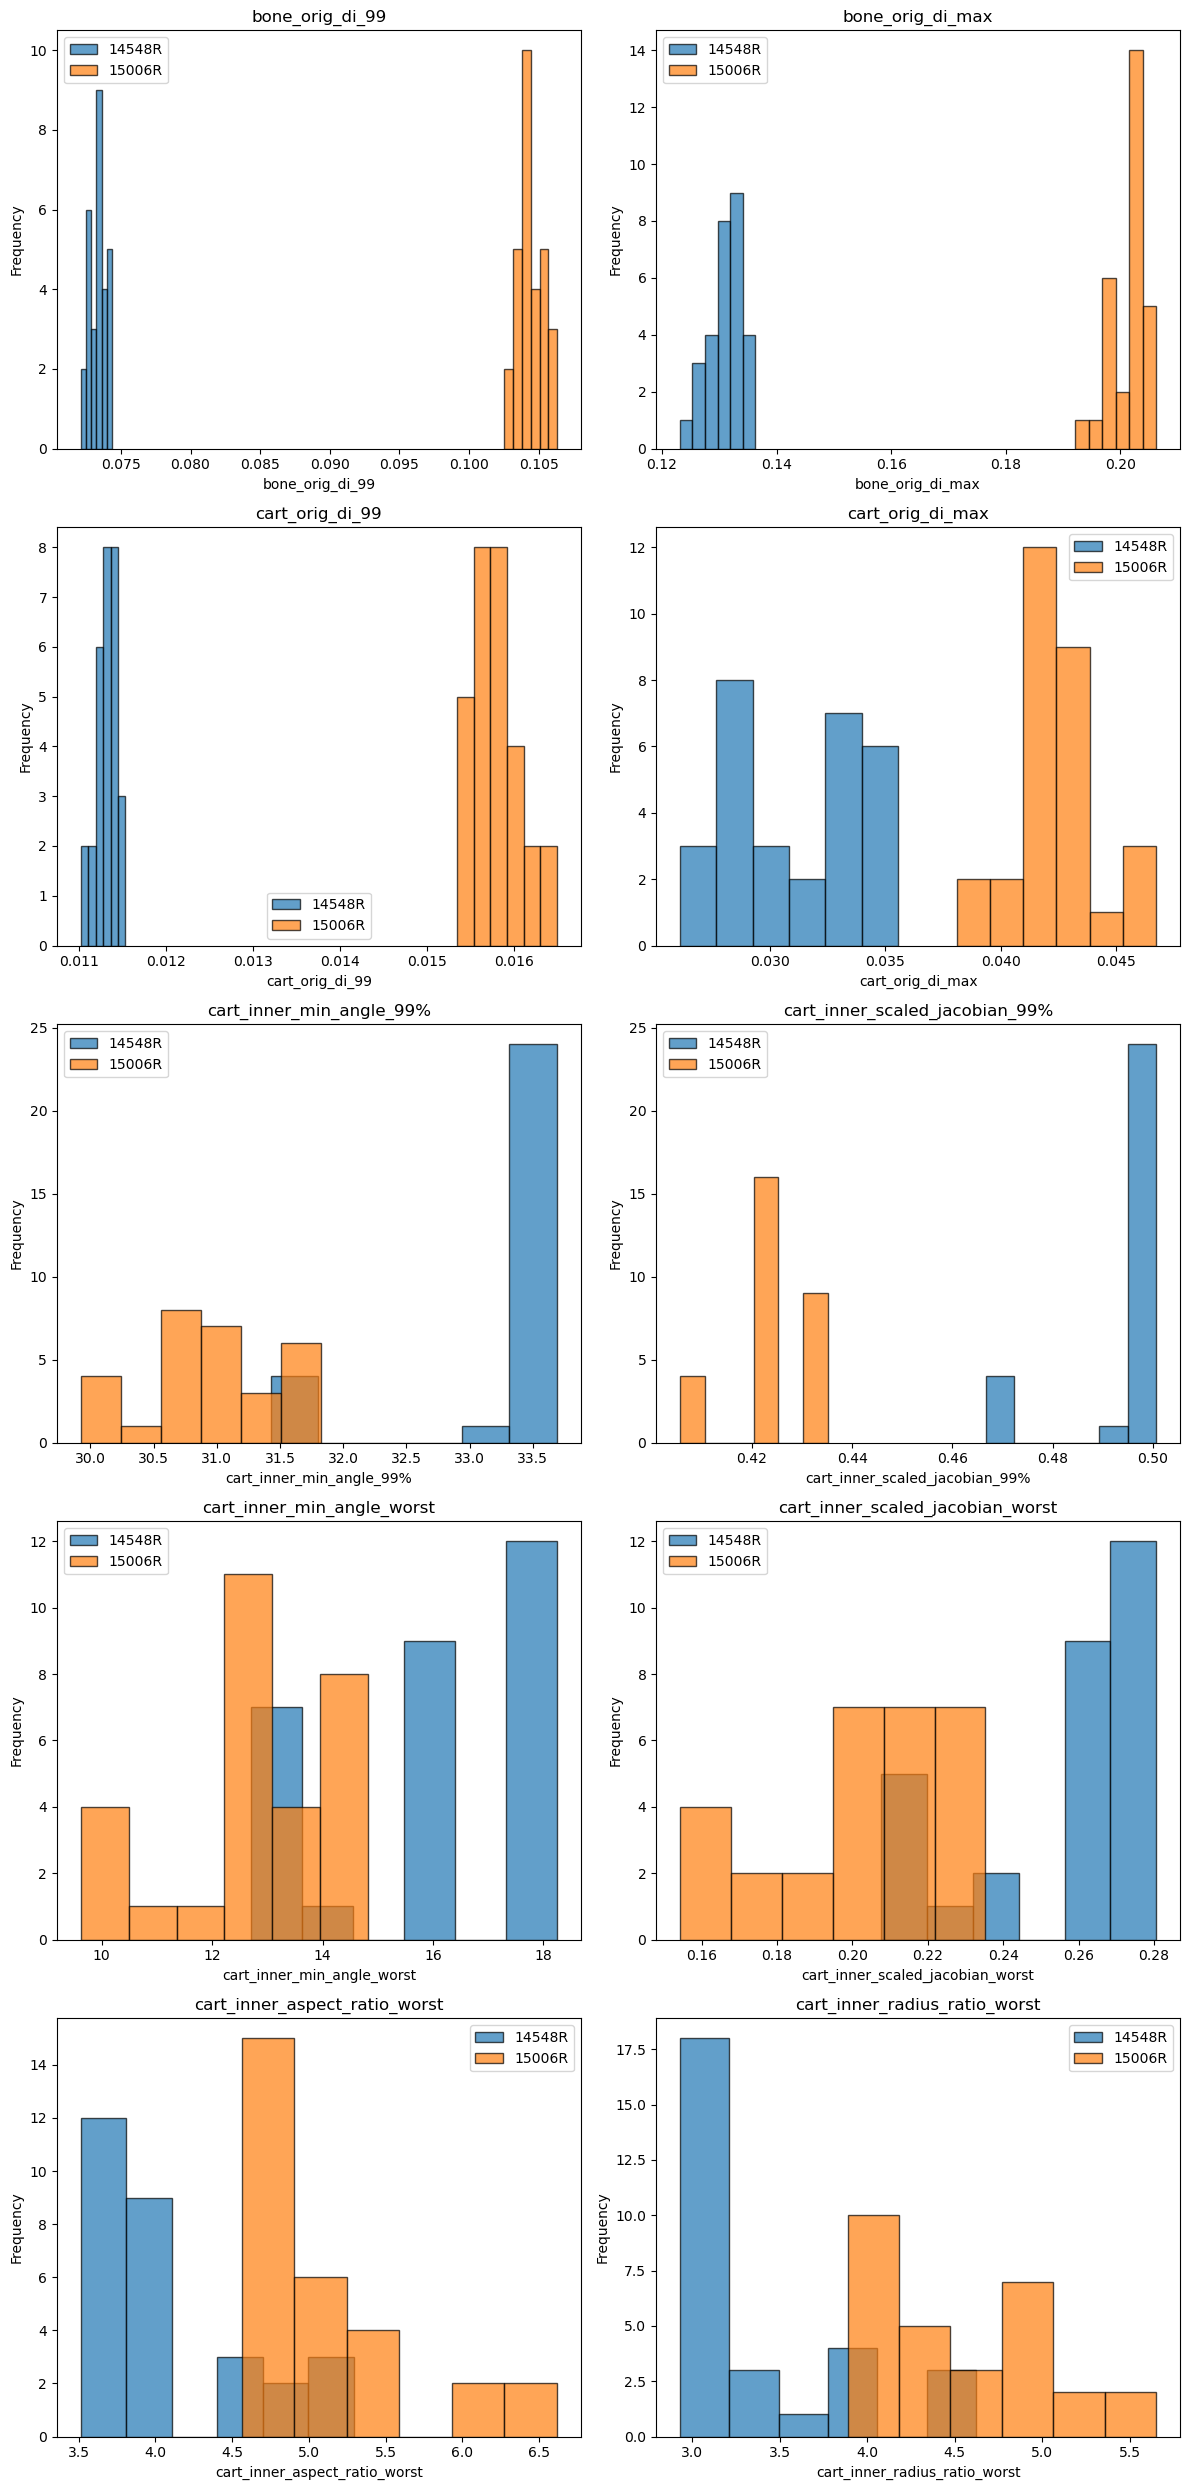

In [6]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()


for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = 6
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        ax[i].legend()

plt.tight_layout()
plt.show()

In [7]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q_weight
    },
    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

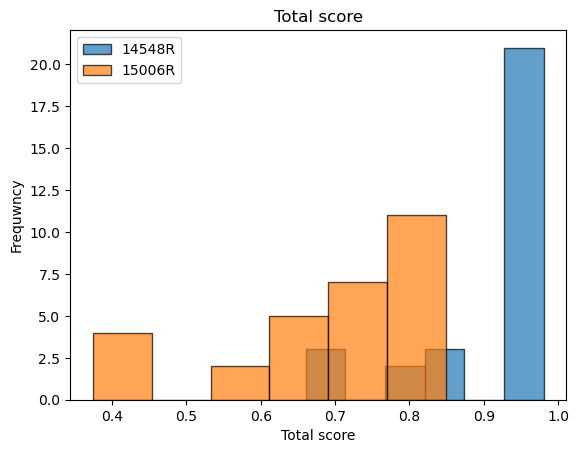

In [8]:
# Get scores

decay = 2
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [9]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.facet_distance.fd_cart_far,cgal_params.facet_distance.fd_cart_near,cgal_params.lloyd.freeze_bound,cgal_params.facet_distance.fd_bone,mean_rank,median_rank,best_rank,n_runs
27,1.00,1.0,0.002,1.0,5.000,5.00,3.5,2
23,0.40,0.4,0.002,4.0,5.000,5.00,3.5,2
22,0.40,0.4,0.002,2.0,5.000,5.00,3.5,2
26,0.80,0.8,0.002,1.0,5.000,5.00,3.5,2
11,0.20,0.2,0.002,1.0,5.000,5.00,3.5,2
16,0.20,0.8,0.002,1.0,8.250,8.25,6.5,2
21,0.40,0.4,0.002,1.0,10.125,6.50,3.5,4
7,0.05,0.8,0.002,1.0,10.250,10.25,6.5,2
13,0.20,0.4,0.002,1.0,10.750,10.75,6.5,2
12,0.20,0.4,0.001,1.0,11.250,11.25,7.0,2


In [10]:
df_score_param

,sub,bone,run_id,cart_inner_min_angle_99%,cart_inner_min_angle_worst,cart_inner_scaled_jacobian_worst,cart_inner_aspect_ratio_worst,cart_inner_radius_ratio_worst,total,rank_within_case,cgal_params.facet_distance.fd_cart_far,cgal_params.facet_distance.fd_cart_near,cgal_params.lloyd.freeze_bound,cgal_params.facet_distance.fd_bone
0,14548R,tpm,1-05b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.40,0.4,0.002,4.0
1,14548R,tpm,0-03b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.20,0.2,0.002,1.0
2,14548R,tpm,8-02b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.20,0.4,0.002,1.0
3,14548R,tpm,10-02b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.20,0.8,0.002,1.0
4,14548R,tpm,14-02b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.40,0.4,0.002,1.0
5,14548R,tpm,2-02b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.05,0.4,0.002,1.0
6,14548R,tpm,16-02b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.40,0.8,0.002,1.0
7,14548R,tpm,1-03b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.40,0.4,0.002,1.0
8,14548R,tpm,2-03b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,0.80,0.8,0.002,1.0
9,14548R,tpm,3-03b,1.000000,1.000000,0.902942,1.000000,1.000000,0.980588,6.5,1.00,1.0,0.002,1.0


In [11]:
df_score_qual[['sub', 'run_id']+[x for x in df_score_qual.columns if 'worst_y' in x]]

,sub,run_id,cart_inner_min_angle_worst_y,cart_inner_radius_ratio_worst_y,cart_inner_aspect_ratio_worst_y,cart_inner_scaled_jacobian_worst_y
0,14548R,1-05b,18.249825,2.929789,3.514271,0.280588
1,14548R,0-03b,18.249825,2.929789,3.514271,0.280588
2,14548R,8-02b,18.249825,2.929789,3.514271,0.280588
3,14548R,10-02b,18.249825,2.929789,3.514271,0.280588
4,14548R,14-02b,18.249825,2.929789,3.514271,0.280588
5,14548R,2-02b,18.249825,2.929789,3.514271,0.280588
6,14548R,16-02b,18.249825,2.929789,3.514271,0.280588
7,14548R,1-03b,18.249825,2.929789,3.514271,0.280588
8,14548R,2-03b,18.249825,2.929789,3.514271,0.280588
9,14548R,3-03b,18.249825,2.929789,3.514271,0.280588


### Thoughts
 - Lloyd ran out of time for all of 15006's 2a runs
 - All 15006 3a onwards with freeze=0.002 runs hit exit code within ~250s
---
 - For Run4, set fd_bone to 0.4 just to see
    - really bad
---
#### Conclusion
- Just set facet distance to a big enough number 
    - for cart, 0.2->1.0 all give equally good results for both subjects
    - for bone, 1.0->4.0 all give equally good results for both subjects
- Reducing fd_bone down to 0.4 resulted in much worse results - This makes me think that for FD not to cause lower cell quality it just needs to be bigger than some number that is dictated by the target element size.
    - And it looks like that number might just be the target element size.
#### Turns out setting the cartilage facet distance to > target size was just allowing it to delete some cells on the surface...
 - Turns out it was doing that even when fd_bone = 0.05...
 - it must be cmobination of increasing min_size to 0.06 and increasing fd_bone that caused the holes
    -  Could set min height to 0.06 in cartilage code
 - Clamping height in cartilage has allowed for higher FD values, without holes, although the element quality is no better...

In [105]:
msh = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/optimise3D/outputs/study4/initialRuns2a/meshes/15006R/tpm-mc1/3Dmesh/mesh-0-0-5.vtu')
msh.plot()

Widget(value='<iframe src="http://localhost:57881/index.html?ui=P_0x30d54dc70_7&reconnect=auto" class="pyvista…

## Try to get a 15006 run with no holes
 - Setting fd_bone = ≤ 0.02 gets rid of the holes
 - it must be cmobination of increasing min_size to 0.06 and increasing fd_bone that caused the holes
    -  Could set min height to 0.06 in cartilage code
- Clamping height in cartilage has allowed for higher FD values, without holes, although the element quality is no better...

In [3]:
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/study4/150016_noHoles_cartClamp/params/full_params.json

SUBJECT: 15006R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 3.938s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 5.539s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 235.449s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [4]:
run = 0
mesh_path = f'outputs/study4/150016_noHoles/meshes/15006R/tpm-mc1/3Dmesh/mesh-0-0-{run}.vtu'
mesh = pv.read(mesh_path)

In [5]:
mesh.plot()

Widget(value='<iframe src="http://localhost:59200/index.html?ui=P_0x33574a120_0&reconnect=auto" class="pyvista…

In [6]:
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells2

q = check_mesh_quality(mesh)
mesh_quality_summary(q, 'tet')

min_angle 7341/366436 cells outside of acceptable range (10, 70.53)
max_angle 345269/366436 cells outside of acceptable range (70.53, 170)
radius_ratio 176/366436 cells outside of acceptable range (1.0, 3.0)
shape 48/366436 cells outside of acceptable range (0.4, 1.0)
aspect_ratio 526/366436 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 40/366436 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 523/366436 cells outside of acceptable range (1.0, 2.0)
condition 131/366436 cells outside of acceptable range (1.0, 3.0)
equiangle_skew 94380/366436 cells outside of acceptable range (0.4, 1.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,54.074989,70.530083,10.639019,"(10, 70.53)",97.996649,7341,"(38.66, 70.53)"
max_angle,8.653764,70.530215,143.262556,"(70.53, 170)",5.776452,345269,"(70.53, 71.75)"
radius_ratio,1.157782,1.000000,8.895245,"(1.0, 3.0)",99.951970,176,"(1.0, 1.43)"
shape,0.898147,1.000000,0.247131,"(0.4, 1.0)",99.986901,48,"(0.75, 1.0)"
aspect_ratio,1.328625,1.000274,7.662183,"(1.0, 3.0)",99.856455,526,"(1.0, 1.7)"
scaled_jacobian,0.738456,0.999758,0.083324,"(0.2, 1.0)",99.989084,40,"(0.5, 1.0)"
aspect_frobenius,1.123484,1.000000,4.046443,"(1.0, 2.0)",99.857274,523,"(1.0, 1.33)"
condition,1.131801,1.000000,6.238304,"(1.0, 3.0)",99.964250,131,"(1.0, 1.36)"
equiangle_skew,0.901250,1.000000,0.177317,"(0.4, 1.0)",74.243797,94380,"(0.64, 1.0)"


In [117]:
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells2

q = check_mesh_quality(mesh)
mesh_quality_summary(q, 'tet')

min_angle 7192/365606 cells outside of acceptable range (10, 70.53)
max_angle 344604/365606 cells outside of acceptable range (70.53, 170)
radius_ratio 179/365606 cells outside of acceptable range (1.0, 3.0)
shape 46/365606 cells outside of acceptable range (0.4, 1.0)
aspect_ratio 537/365606 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 39/365606 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 532/365606 cells outside of acceptable range (1.0, 2.0)
condition 117/365606 cells outside of acceptable range (1.0, 3.0)
equiangle_skew 94137/365606 cells outside of acceptable range (0.4, 1.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,54.059385,70.529908,7.610408,"(10, 70.53)",98.032855,7192,"(38.58, 70.53)"
max_angle,8.622414,70.529785,142.852762,"(70.53, 170)",5.744435,344604,"(70.53, 71.72)"
radius_ratio,1.158119,1.000001,6.649765,"(1.0, 3.0)",99.951040,179,"(1.0, 1.43)"
shape,0.898066,0.999999,0.247367,"(0.4, 1.0)",99.987418,46,"(0.75, 1.0)"
aspect_ratio,1.329146,1.000571,7.662388,"(1.0, 3.0)",99.853121,537,"(1.0, 1.7)"
scaled_jacobian,0.738488,0.999267,0.083176,"(0.2, 1.0)",99.989333,39,"(0.5, 1.0)"
aspect_frobenius,1.123689,1.000001,4.042583,"(1.0, 2.0)",99.854488,532,"(1.0, 1.33)"
condition,1.132129,1.000001,6.235232,"(1.0, 3.0)",99.967998,117,"(1.0, 1.36)"
equiangle_skew,0.900990,1.000000,0.126840,"(0.4, 1.0)",74.251790,94137,"(0.64, 1.0)"


In [122]:
plot_bad_cells2(mesh, q, 'scaled_jacobian', [0, 0.15])

scaled_jacobian
Bad cells =  9


Widget(value='<iframe src="http://localhost:57881/index.html?ui=P_0x36da615e0_16&reconnect=auto" class="pyvist…

# Try optimising FD again
- range of FD and lower freeze
 - Best results:
     - Freeze = 0.0005
     - high time limit ≥360s
     - fd_near == far  = ~0.5
     - perturb = 20
---
#### I think the future plan should be to run a more well thought out and executed study that:
- Uses subjects that cover the range of mesh properties
- loops over:
    - perturb sliver bound
    - lloyd freeze_bound with chosen max time limit
    - maybe include exude sliver bound and odt if possible
    - Was going to say maybe even include taper shape but I think that would overfit to chosen meshes.
    - also taper element size - but this might overfit to chosen subjects
    - Also have a feeling denser 2dmesh input for cartilage generation would give smoother cartilage edge and help with element quality
- Then use the grouped average df of mean score placement to decide on optimal paramters

In [ ]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from tqdm import tqdm
import subprocess

In [142]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('outputs/study4') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study4') # path dir to save outputs in

study_prefix = 'MoreRuns' # start of dir name of output_root in set_parameters
studies = ['1a', '1b', '1c', '1d', '2a', '2b', '2c', '2d'] # individual study identifier (end of dir name of output_root in set_parameters)

In [143]:
# ORGANISE AND SAVE DATA

params1 = get_params3d(root_dir, study_prefix, studies[0:2])
params1['cgal_params.lloyd.freeze_bound'] = [0.002] * len(params1)
params1['cgal_params.lloyd.convergence'] = [0.0025] * len(params1)
params1['cgal_params.odt.freeze_bound'] = [0.0] * len(params1)
params1['cgal_params.odt.convergence'] = [0.0] * len(params1)
params1['cgal_params.optimisation.lloyd'] = [True] * len(params1)
params1['cgal_params.optimisation.odt'] = [False] * len(params1)

params2 = get_params3d(root_dir, study_prefix, studies[2:4])
params2['cgal_params.lloyd.convergence'] = [0.001] * len(params2)
params2['cgal_params.odt.freeze_bound'] = [0.0] * len(params2)
params2['cgal_params.odt.convergence'] = [0.0] * len(params2)
params2['cgal_params.optimisation.lloyd'] = [True] * len(params2)
params2['cgal_params.optimisation.odt'] = [False] * len(params2)

params3 = get_params3d(root_dir, study_prefix, studies[4:5])
params3['cgal_params.lloyd.freeze_bound'] = [0.0] * len(params3)
params3['cgal_params.lloyd.convergence'] = [0.0] * len(params3)
params3['cgal_params.perturb.sliver_bound'] = [20] * len(params3)
params3['cgal_params.facet_distance.fd_cart_near'] = [0.5] * len(params3)
params3['cgal_params.odt.freeze_bound'] = [0.0] * len(params3)
params3['cgal_params.odt.convergence'] = [0.0] * len(params3)
params3['cgal_params.optimisation.lloyd'] = [True] * len(params3)
params3['cgal_params.optimisation.odt'] = [False] * len(params3)

params4 = get_params3d(root_dir, study_prefix, studies[5:6])
params4['cgal_params.lloyd.freeze_bound'] = [0.0] * len(params4)
params4['cgal_params.lloyd.convergence'] = [0.0] * len(params4)
params4['cgal_params.perturb.sliver_bound'] = [20] * len(params4)
params4['cgal_params.facet_distance.fd_cart_near'] = [0.5] * len(params4)
params4['cgal_params.odt.freeze_bound'] = [0.0] * len(params4)
params4['cgal_params.odt.convergence'] = [0.0] * len(params4)
params4['cgal_params.optimisation.lloyd'] = [False] * len(params4)
params4['cgal_params.optimisation.odt'] = [True] * len(params4)

params5 = get_params3d(root_dir, study_prefix, studies[6:7])
params5['cgal_params.lloyd.freeze_bound'] = [0.0005] * len(params5)
params5['cgal_params.lloyd.convergence'] = [0.0] * len(params5)
params5['cgal_params.perturb.sliver_bound'] = [20] * len(params5)
params5['cgal_params.facet_distance.fd_cart_near'] = [0.5] * len(params5)
params5['cgal_params.odt.freeze_bound'] = [0.0005] * len(params5)
params5['cgal_params.odt.convergence'] = [0.0] * len(params5)
params5['cgal_params.optimisation.lloyd'] = [True] * len(params5)
params5['cgal_params.optimisation.odt'] = [True] * len(params5)

params6 = get_params3d(root_dir, study_prefix, studies[7:8])
params6['cgal_params.lloyd.freeze_bound'] = [0.0] * len(params6)
params6['cgal_params.lloyd.convergence'] = [0.0] * len(params6)
params6['cgal_params.perturb.sliver_bound'] = [20] * len(params6)
params6['cgal_params.facet_distance.fd_cart_near'] = [0.5] * len(params6)
params6['cgal_params.odt.freeze_bound'] = [0.0005] * len(params6)
params6['cgal_params.odt.convergence'] = [0.0] * len(params6)
params6['cgal_params.optimisation.lloyd'] = [False] * len(params6)
params6['cgal_params.optimisation.odt'] = [True] * len(params6)

pd.concat((params1, params2, params3, params4, params5, params6)).to_csv(out_dir / 'params-M.csv', index=False)
get_runtimes(root_dir, study_prefix, studies).to_csv(out_dir / 'runtimes-M.csv', index=False)

info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, [
                                        'MoreRuns1a-01a', 'MoreRuns1b-01b',
                                        'MoreRuns1c-01c', 'MoreRuns1d-01d',
                                        'MoreRuns2a-02a',
                                        'MoreRuns2b-02b',
                                        'MoreRuns2c-02c',
                                        'MoreRuns2d-02d',
                                        ])

df_bone.to_csv(out_dir / 'df_bone-M.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart-M.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual-M.csv', index=False)

In [12]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone-M.csv')
df_cart = pd.read_csv(out_dir / 'df_cart-M.csv')
df_qual = pd.read_csv(out_dir / 'df_qual-M.csv')


df_run = pd.read_csv(out_dir / 'runtimes-M.csv')
df_param = pd.read_csv(out_dir / 'params-M.csv')
df_param

,sub,bone,run_id,cgal_params.facet_distance.fd_cart_near,cgal_params.perturb.sliver_bound,cgal_params.lloyd.freeze_bound,cgal_params.lloyd.convergence,cgal_params.odt.freeze_bound,cgal_params.odt.convergence,cgal_params.optimisation.lloyd,cgal_params.optimisation.odt
0,15006R,tpm,0-01a,0.2,0,0.0020,0.0025,0.0000,0.0,True,False
1,15006R,tpm,1-01a,0.2,15,0.0020,0.0025,0.0000,0.0,True,False
2,15006R,tpm,2-01a,0.2,20,0.0020,0.0025,0.0000,0.0,True,False
3,15006R,tpm,3-01a,0.4,0,0.0020,0.0025,0.0000,0.0,True,False
4,15006R,tpm,4-01a,0.4,15,0.0020,0.0025,0.0000,0.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...
57,14548R,tpm,0-02b,0.5,20,0.0000,0.0000,0.0000,0.0,False,True
58,15006R,tpm,0-02c,0.5,20,0.0005,0.0000,0.0005,0.0,True,True
59,14548R,tpm,0-02c,0.5,20,0.0005,0.0000,0.0005,0.0,True,True
60,15006R,tpm,0-02d,0.5,20,0.0000,0.0000,0.0005,0.0,False,True


In [20]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'total_tets',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]
#df = df[df['sub']=='15006R']
#df = df[df['sub']=='14548R']

print(len(df))

62



15006R
 - Average edge length: 0.4439 mm
 -   Max element count: 316829

14548R
 - Average edge length: 0.3605 mm
 -   Max element count: 178068


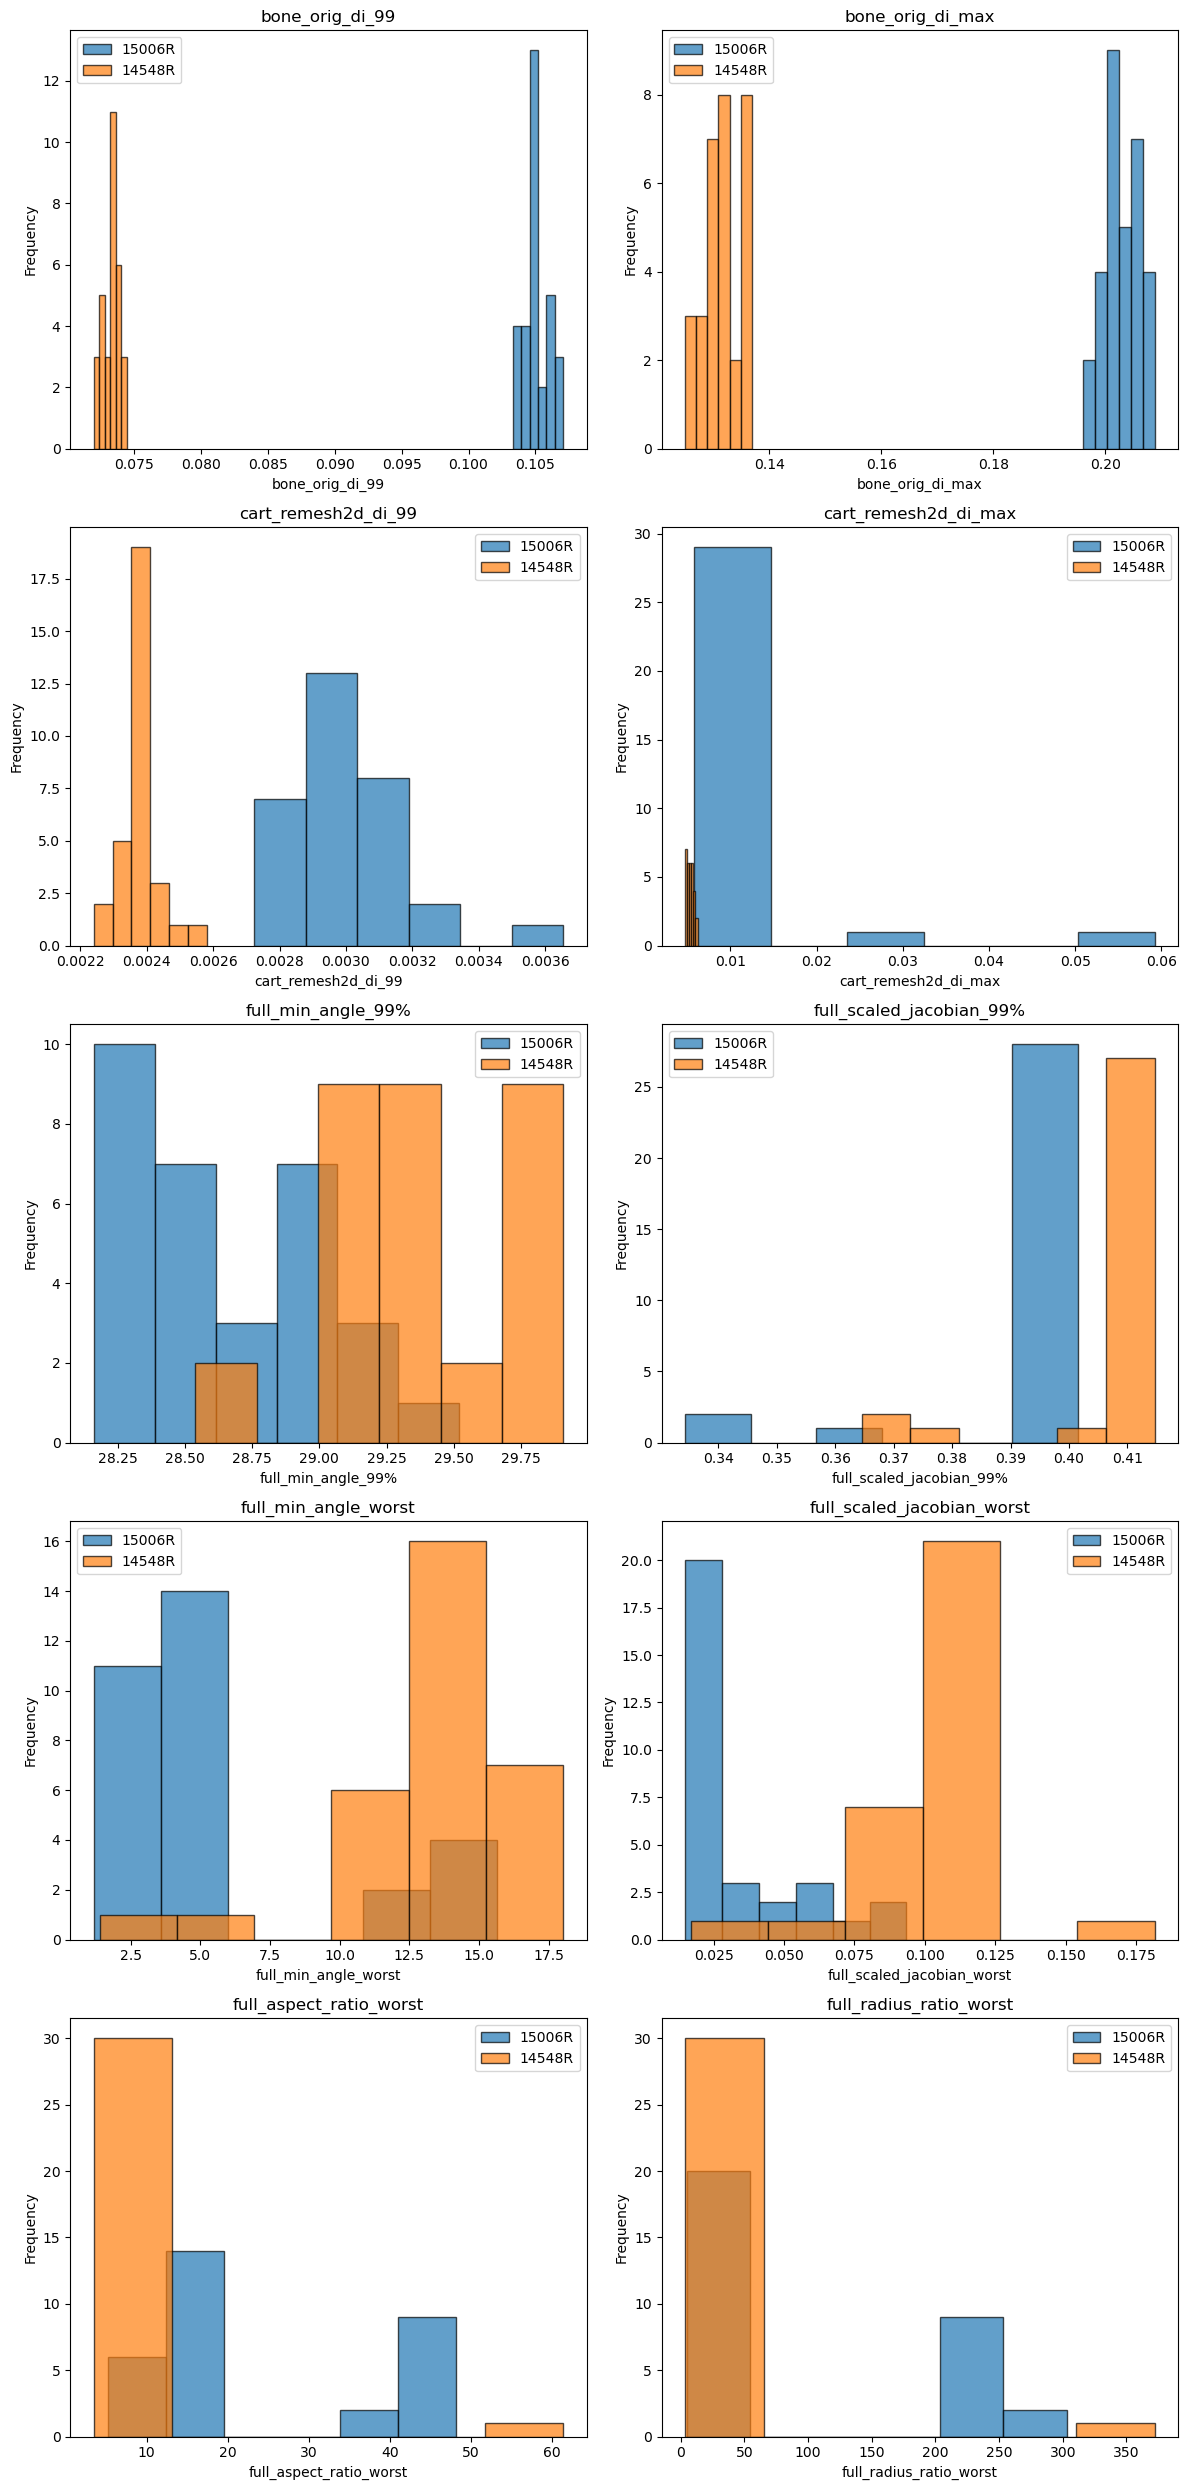

In [21]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()


for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = 6
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        ax[i].legend()

plt.tight_layout()
plt.show()

In [163]:
# holes
df[df['cart_remesh2d_di_max']>0.025]

,sub,bone,run_id,bone_orig_di_99,bone_orig_di_max,remesh3d_vol,cart_remesh2d_di_99,cart_remesh2d_di_max,cart_inner_min_angle_99%,cart_inner_scaled_jacobian_99%,cart_inner_min_angle_worst,cart_inner_scaled_jacobian_worst,cart_inner_aspect_ratio_99%,cart_inner_radius_ratio_99%,cart_inner_aspect_ratio_worst,cart_inner_radius_ratio_worst,total_tets
56,15006R,tpm,0-02b,0.107072,0.208825,1899.358697,0.002979,0.027349,32.011722,0.363371,14.670208,0.183897,1.894220,1.592770,4.020446,3.289511,315975
60,15006R,tpm,0-02d,0.105029,0.202244,1894.044212,0.003654,0.059203,31.144819,0.349708,12.118067,0.163937,1.961792,1.646967,5.034494,4.151700,316829


In [155]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/optimise3D/outputs/study4/MoreRuns2b/meshes/15006R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu'
pv.read(path).plot()



Widget(value='<iframe src="http://localhost:59200/index.html?ui=P_0x352938080_6&reconnect=auto" class="pyvista…

In [22]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

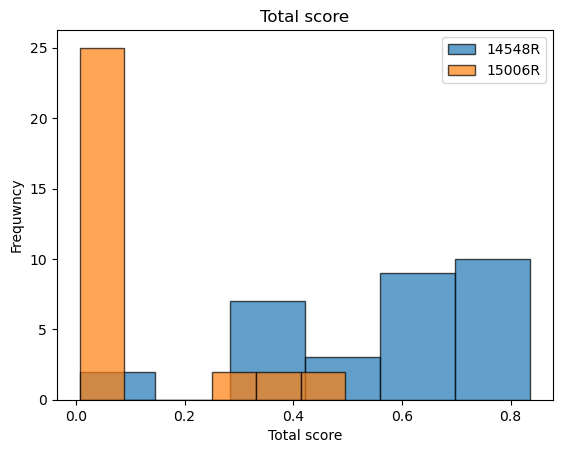

In [23]:
# Get scores

decay = 2
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [29]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.facet_distance.fd_cart_near,cgal_params.perturb.sliver_bound,cgal_params.lloyd.freeze_bound,cgal_params.lloyd.convergence,cgal_params.odt.freeze_bound,cgal_params.odt.convergence,cgal_params.optimisation.lloyd,cgal_params.optimisation.odt,mean_rank,median_rank,best_rank,n_runs
15,0.4,20,0.0005,0.0010,0.0000,0.0,True,False,6.50,6.50,1.0,2
28,0.8,20,0.0005,0.0010,0.0000,0.0,True,False,8.50,8.50,5.0,2
25,0.8,15,0.0005,0.0010,0.0000,0.0,True,False,10.00,10.00,2.0,2
6,0.2,20,0.0005,0.0010,0.0000,0.0,True,False,10.50,10.50,9.0,2
20,0.5,20,0.0000,0.0000,0.0005,0.0,False,True,11.00,11.00,1.0,2
26,0.8,15,0.0010,0.0010,0.0000,0.0,True,False,11.25,11.25,7.5,2
4,0.2,15,0.0010,0.0010,0.0000,0.0,True,False,11.25,11.25,7.5,2
16,0.4,20,0.0010,0.0010,0.0000,0.0,True,False,11.25,11.25,7.5,2
13,0.4,15,0.0010,0.0010,0.0000,0.0,True,False,11.25,11.25,7.5,2
29,0.8,20,0.0010,0.0010,0.0000,0.0,True,False,11.25,11.25,7.5,2


In [25]:
df_score_param[df_score_param['sub']=='15006R']

,sub,bone,run_id,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,total,rank_within_case,cgal_params.facet_distance.fd_cart_near,cgal_params.perturb.sliver_bound,cgal_params.lloyd.freeze_bound,cgal_params.lloyd.convergence,cgal_params.odt.freeze_bound,cgal_params.odt.convergence,cgal_params.optimisation.lloyd,cgal_params.optimisation.odt
22,15006R,tpm,11-01d,1.000000,0.034871,3.191473e-01,6.250058e-01,0.494756,1.0,0.4,20,0.0005,0.0010,0.0000,0.0,True,False
23,15006R,tpm,16-01d,1.000000,0.029718,1.424168e-01,5.165337e-01,0.422167,2.0,0.8,15,0.0005,0.0010,0.0000,0.0,True,False
25,15006R,tpm,0-02a,0.874788,0.040891,9.827198e-02,5.262736e-01,0.385056,3.0,0.5,20,0.0000,0.0000,0.0000,0.0,True,False
26,15006R,tpm,0-02c,0.880604,0.033324,7.697218e-02,4.091108e-01,0.350003,4.0,0.5,20,0.0005,0.0000,0.0005,0.0,True,True
33,15006R,tpm,17-01d,0.806067,0.059411,1.291050e-01,1.215770e-01,0.279040,5.0,0.8,20,0.0005,0.0010,0.0000,0.0,True,False
34,15006R,tpm,15-01d,0.709413,0.048793,1.291050e-01,1.215770e-01,0.252222,6.0,0.8,0,0.0005,0.0010,0.0000,0.0,True,False
36,15006R,tpm,10-01d,0.064072,0.020665,3.248653e-08,1.161311e-06,0.021184,7.0,0.4,15,0.0005,0.0010,0.0000,0.0,True,False
37,15006R,tpm,9-01d,0.063643,0.020791,3.368281e-08,8.987876e-07,0.021109,8.0,0.4,0,0.0005,0.0010,0.0000,0.0,True,False
38,15006R,tpm,5-01d,0.063599,0.020810,3.394980e-08,8.681279e-07,0.021103,9.0,0.2,20,0.0005,0.0010,0.0000,0.0,True,False
39,15006R,tpm,3-01d,0.063457,0.020856,3.440170e-08,7.865101e-07,0.021078,10.0,0.2,0,0.0005,0.0010,0.0000,0.0,True,False


In [28]:
df_score_param[df_score_param['sub']=='14548R']

,sub,bone,run_id,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,total,rank_within_case,cgal_params.facet_distance.fd_cart_near,cgal_params.perturb.sliver_bound,cgal_params.lloyd.freeze_bound,cgal_params.lloyd.convergence,cgal_params.odt.freeze_bound,cgal_params.odt.convergence,cgal_params.optimisation.lloyd,cgal_params.optimisation.odt
0,14548R,tpm,0-02d,1.000000,0.346227,1.000000e+00,1.000000e+00,0.836557,1.0,0.5,20,0.0000,0.0000,0.0005,0.0,False,True
1,14548R,tpm,2-01b,1.000000,0.072124,9.684372e-01,9.590462e-01,0.749902,3.0,0.2,20,0.0020,0.0025,0.0000,0.0,True,False
2,14548R,tpm,8-01b,1.000000,0.072124,9.684372e-01,9.590462e-01,0.749902,3.0,0.8,20,0.0020,0.0025,0.0000,0.0,True,False
3,14548R,tpm,5-01b,1.000000,0.072124,9.684372e-01,9.590462e-01,0.749902,3.0,0.4,20,0.0020,0.0025,0.0000,0.0,True,False
4,14548R,tpm,14-01c,0.944887,0.111440,9.752545e-01,7.699472e-01,0.700382,7.5,0.8,20,0.0010,0.0010,0.0000,0.0,True,False
5,14548R,tpm,8-01c,0.944887,0.111440,9.752545e-01,7.699472e-01,0.700382,7.5,0.4,20,0.0010,0.0010,0.0000,0.0,True,False
6,14548R,tpm,7-01c,0.944887,0.111440,9.752545e-01,7.699472e-01,0.700382,7.5,0.4,15,0.0010,0.0010,0.0000,0.0,True,False
7,14548R,tpm,2-01c,0.944887,0.111440,9.752545e-01,7.699472e-01,0.700382,7.5,0.2,20,0.0010,0.0010,0.0000,0.0,True,False
8,14548R,tpm,1-01c,0.944887,0.111440,9.752545e-01,7.699472e-01,0.700382,7.5,0.2,15,0.0010,0.0010,0.0000,0.0,True,False
9,14548R,tpm,13-01c,0.944887,0.111440,9.752545e-01,7.699472e-01,0.700382,7.5,0.8,15,0.0010,0.0010,0.0000,0.0,True,False


In [30]:
df_score_qual[['sub', 'run_id']+[x for x in df_score_qual.columns if 'worst_y' in x]].head(15)

,sub,run_id,full_min_angle_worst_y,full_radius_ratio_worst_y,full_aspect_ratio_worst_y,full_scaled_jacobian_worst_y
0,14548R,0-02d,18.017296,3.537871,3.459270,0.181624
1,14548R,2-01b,18.008032,4.081908,4.063126,0.103189
2,14548R,8-01b,18.008032,4.081908,4.063126,0.103189
3,14548R,5-01b,18.008032,4.081908,4.063126,0.103189
4,14548R,14-01c,14.448872,4.460106,4.049491,0.124944
5,14548R,8-01c,14.448872,4.460106,4.049491,0.124944
6,14548R,7-01c,14.448872,4.460106,4.049491,0.124944
7,14548R,2-01c,14.448872,4.460106,4.049491,0.124944
8,14548R,1-01c,14.448872,4.460106,4.049491,0.124944
9,14548R,13-01c,14.448872,4.460106,4.049491,0.124944


In [99]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/optimise3D/outputs/study4/MoreRuns1d/meshes/15006R/tpm-mc1/3Dmesh/mesh-0-0-11.vtu'
pv.read(path).plot()



Widget(value='<iframe src="http://localhost:59200/index.html?ui=P_0x34f599460_3&reconnect=auto" class="pyvista…

In [176]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/optimise3D/outputs/study4/MoreRuns1c/meshes/14548R/tpm-mc1/3Dmesh/mesh-0-0-11.vtu'
pv.read(path).plot()


Widget(value='<iframe src="http://localhost:59200/index.html?ui=P_0x34e685ca0_7&reconnect=auto" class="pyvista…